In [1]:
import PF_wrapper as PF

In [2]:
dir1 = "training_output"
dir2 = "testing_output"

In [14]:
'''PF.train("Data/proteins_train_data.txt", test_file="Data/proteins_val_data.txt", 
         train_labels="Data/proteins_train_labels.txt", test_labels="Data/proteins_val_data.txt", 
         model_name="Proteins", output_directory=dir1, data_dimension=2,
         distances=["javadistance:userdistances.jar:com.example.SpectralDistance",
                   "javadistance:userdistances.jar:com.example.ApproximateGraphEditDistance",
                   "javadistance:userdistances.jar:com.example.GraphletDistance",
                   "javadistance:userdistances.jar:com.example.ShortestPathDistance",
                   "javadistance:userdistances.jar:com.example.WLDistance",
                   "javadistance:userdistances.jar:com.example.LaplacianSpectralDistance",
                   "javadistance:userdistances.jar:com.example.NormalizedLaplacianSpectralDistance"],
         numeric_data=False, num_trees=2
         )'''

'''PF.train("Data/proteins_train_data2.txt", test_file="Data/proteins_val_data2.txt", 
         train_labels="Data/proteins_train_labels2.txt", test_labels="Data/proteins_val_data2.txt", 
         model_name="Proteins", output_directory=dir1, data_dimension=2,
         distances=["javadistance:userdistances.jar:com.example.SpectralDistance",
                   "javadistance:userdistances.jar:com.example.ApproximateGraphEditDistance",
                   "javadistance:userdistances.jar:com.example.WLDistance",
                   "javadistance:userdistances.jar:com.example.LaplacianSpectralDistance",
                   "javadistance:userdistances.jar:com.example.NormalizedLaplacianSpectralDistance"],
         numeric_data=False, num_trees=2
         )'''

PF.train("Data/proteins_train_data2.txt", test_file="Data/proteins_val_data2.txt", 
         train_labels="Data/proteins_train_labels2.txt", test_labels="Data/proteins_val_labels2.txt", 
         model_name="Proteins", output_directory=dir1, data_dimension=2,
         distances=["WLDistance2"], return_predictions=True, return_proximities=True,
        num_trees=11, parallel_trees=True
         )


0:3mb
finished in 0:0:0.087

0:20mb
finished in 0:0:0.402

-----------------Repetition No: 1 (proteins_train_data2.txt)   -----------------
Using: 32 MB, Free: 88 MB, Allocated Pool: 120 MB, Max Available: 1024 MB
core.ProximityForestResult@7cd84586
4.2.3.1.6.7.0.5.8.9.10.
Using: 97 MB, Free: 185 MB, Allocated Pool: 282 MB, Max Available: 1024 MB
**
Training Time: 188265.002921ms (0:3:8.265)
Prediction Time: 5349.543371ms (0:0:5.349)
Correct(TP+TN): 78 vs Incorrect(FP+FN): 33
Score: 0.7027027027027027
Error Rate: 0.29729729729729726
REPEAT:1 ,proteins_train_data2.txt, 0.7027027027027027, 188265.002921, 5349.543371, 25.818181818181817
Computing Training Proximities...
Done Computing Training Proximities. Computation time: 7191.0ms
Computing Test/Train Proximities...
Done Computing Test/Train Proximities. Computation time: 1522.0ms


In [15]:
PF.predict(dir1 + "/Proteins", "Data/proteins_test_data2.txt", test_labels="Data/proteins_test_labels2.txt", 
         data_dimension=2, return_predictions=True
         )


0:58mb
finished in 0:0:0.130
**
Training Time: 188265.002921ms (0:3:8.265)
Prediction Time: 16735.041973ms (0:0:16.735)
Correct(TP+TN): 87 vs Incorrect(FP+FN): 25
Score: 0.7767857142857143
Error Rate: 0.2232142857142857
REPEAT:1 ,proteins_train_data2.txt, 0.7767857142857143, 188265.002921, 16735.041973, 25.818181818181817


In [16]:
PF.predict(dir1 + "/Proteins", "Data/proteins_train_data2.txt", test_labels="Data/proteins_train_labels2.txt", 
         data_dimension=2,
         )


0:58mb
finished in 0:0:0.342
*********
Training Time: 188265.002921ms (0:3:8.265)
Prediction Time: 117314.767932ms (0:1:57.314)
Correct(TP+TN): 879 vs Incorrect(FP+FN): 11
Score: 0.9876404494382023
Error Rate: 0.012359550561797716
REPEAT:1 ,proteins_train_data2.txt, 0.9876404494382023, 188265.002921, 117314.767932, 25.818181818181817


In [17]:
p = PF.getArray(dir1 + "/TrainingProximities.txt")

In [18]:
p.shape

(890, 890)

In [19]:
from sklearn.manifold import MDS

In [20]:
mds = MDS(n_components=2, random_state=0, metric=True, dissimilarity="precomputed")

In [21]:
Xt = mds.fit_transform(0.5*(p + p.transpose()))

/home/ben/.local/lib/python3.13/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


In [22]:
import matplotlib.pyplot as plt

In [32]:
import numpy as np
import pandas as pd

In [36]:
#f0 = open("Data/proteins_train_labels2.txt")
#f1 = f0.read()
##y_train = eval("np.array(" + f1 + ")")
#y_train = np.array(f1)
#f0.close()
y_train = pd.read_csv("Data/proteins_train_labels2.txt", header=None)

In [39]:
y_train[0]

0      1
1      0
2      1
3      0
4      0
      ..
885    0
886    1
887    1
888    0
889    0
Name: 0, Length: 890, dtype: int64

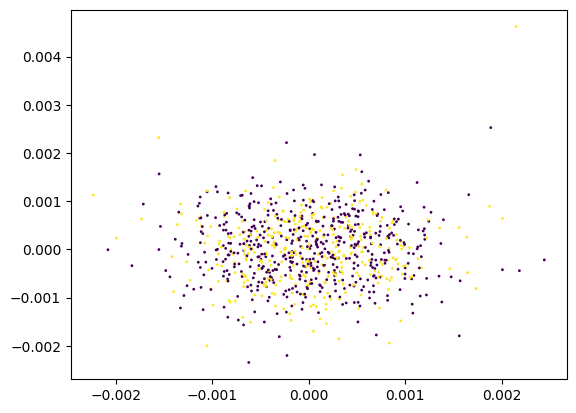

In [40]:
plt.scatter(Xt.transpose()[0],Xt.transpose()[1], s=1.0, c=y_train[0])

In [4]:
PF.predict(dir1 + "/Proteins", "Data/proteins_test_data2.txt", test_labels="Data/proteins_test_data2.txt", 
         data_dimension=2, numeric_data=False, return_predictions=True
         )


Fatal Error:: com.example.SpectralDistance

java.lang.ClassNotFoundException: com.example.SpectralDistance
	at java.base/jdk.internal.loader.BuiltinClassLoader.loadClass(BuiltinClassLoader.java:641)
	at java.base/jdk.internal.loader.ClassLoaders$AppClassLoader.loadClass(ClassLoaders.java:188)
	at java.base/java.lang.ClassLoader.loadClass(ClassLoader.java:525)
	at java.base/java.lang.Class.forName0(Native Method)
	at java.base/java.lang.Class.forName(Class.java:467)
	at java.base/java.io.ObjectInputStream.resolveClass(ObjectInputStream.java:773)
	at java.base/java.io.ObjectInputStream.readNonProxyDesc(ObjectInputStream.java:2034)
	at java.base/java.io.ObjectInputStream.readClassDesc(ObjectInputStream.java:1898)
	at java.base/java.io.ObjectInputStream.readOrdinaryObject(ObjectInputStream.java:2224)
	at java.base/java.io.ObjectInputStream.readObject0(ObjectInputStream.java:1733)
	at java.base/java.io.ObjectInputStream$FieldValues.<init>(ObjectInputStream.java:2606)
	at java.base/java.io.